<a href="https://colab.research.google.com/github/Mohamed-Hesham-Latif/ML-55-25005/blob/main/Exercise6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [1]:
import pandas as pd

data = pd.read_csv("heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [2]:
X = data.drop('target', axis=1)
y = data['target']

**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [3]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# X → features, y → target
# test_size=0.1 → 10% of data used for testing
# random_state=101 → ensures same split every time (reproducibility)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101
)

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

## Naive Bayes Model

**TASK: Create Naive Bayes model

In [4]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler ONLY on training data and transform it
# This learns mean & std from training set
X_train = scaler.fit_transform(X_train)

# Use the same scaler to transform test data (no fitting here!)
# This prevents data leakage
X_test = scaler.transform(X_test)

In [5]:
from sklearn.naive_bayes import GaussianNB

# Create Naive Bayes model
model = GaussianNB()

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

Confusion Matrix:
[[13  2]
 [ 2 14]]


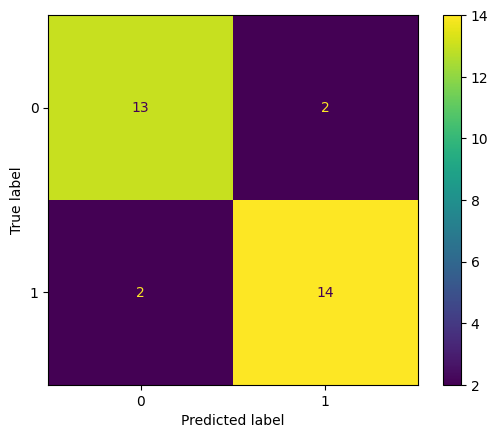

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.88      0.88      0.88        16

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31



In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Train the Naive Bayes model using the training data
model.fit(X_train, y_train)

# Predict the target values for the test data
y_pred = model.predict(X_test)

# Create the confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix array
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Display the plot
plt.show()

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [8]:
import numpy as np
import pandas as pd

# Create patient data
patient = np.array([[48.0, 0.0, 2.0, 130.0, 275.0, 0.0, 1.0,
                     139.0, 0.0, 0.2, 2.0, 0.0, 2.0]])

# Convert to DataFrame with same column names as training data
patient_df = pd.DataFrame(patient, columns=X.columns)

# Scale using the same scaler (no warning now)
patient_scaled = scaler.transform(patient_df)

# Predict class
prediction = model.predict(patient_scaled)

# Predict probability
probability = model.predict_proba(patient_scaled)

# Output results
print("Prediction (0 = No disease, 1 = Disease):", prediction[0])
print("Prediction Probability:", probability[0])

Prediction (0 = No disease, 1 = Disease): 1
Prediction Probability: [0.00113704 0.99886296]
